In [32]:
import torch
import imageio.v2 as imageio
import os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import cv2
import matplotlib.pyplot as plt
import math
from torch.fft import fft2, fftshift, ifft2, ifftshift
from PIL import Image
import scipy.ndimage
import numpy as np
from scipy import ndimage
import random
import copy
from torchvision import transforms

In [33]:
def gen_gauss_psf(sigma_x, sigma_y, bg_size=51):
    center_x = bg_size // 2
    center_y = bg_size // 2

    x = torch.arange(0, bg_size) - center_x
    y = torch.arange(0, bg_size) - center_y
    xx, yy = torch.meshgrid(x, y, indexing='ij')

    gaussian_psf = torch.exp(-((xx ** 2) / (2 * sigma_x ** 2) + (yy ** 2) / (2 * sigma_y ** 2)))
    gaussian_psf /= torch.sum(gaussian_psf)

    return gaussian_psf

def rotate_psf(psf, angle):
    rotated_psf = scipy.ndimage.rotate(psf.numpy(), angle, reshape=False, order=1)
    return torch.tensor(rotated_psf)

def get_psf(z):    
    psf = gen_gauss_psf(3, 0.5)
    rotated_psf = rotate_psf(psf, ((z-2) / 78) * 90)

    return rotated_psf

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [35]:
images_path = "/home/abc256/mono/DENSE/train/train_sequence_00_town01/rgb/frames"

img = Image.open(os.path.join(images_path, "frame_0000000000.png")).convert("RGB")

transform = transforms.ToTensor()
img = transform(img)
img = img.to(device)

print(img.shape)

torch.Size([3, 260, 346])


In [36]:
depths_path = "/home/abc256/mono/DENSE/train/train_sequence_00_town01/depth/data"

depth = np.load(os.path.join(depths_path, "depth_0000000000.npy"))
depth = torch.from_numpy(depth)

min_depth = 2
max_depth = 80

depth = torch.clamp(depth, min=min_depth, max=max_depth)
depth = depth.to(device)

depth_bins = torch.round(depth)
depth_bins = depth_bins.to(device)


In [37]:
final_image = torch.zeros_like(img)
final_image = final_image.to(device)

masked_img = torch.zeros_like(img)
masked_img = masked_img.to(device)

psf = torch.zeros(51,51)
psf = psf.to(device)

for i in range(min_depth, max_depth+1):
    mask = depth_bins == torch.tensor(i, dtype=torch.float64)
    masked_img = img.clone()
    masked_img[:,~mask] = 0

    psf = get_psf(i)
    psf = torch.unsqueeze(torch.unsqueeze(psf, 0), 0)
    psf = psf.repeat(3, 1, 1, 1)
    psf = torch.flip(psf, dims=[-2, -1])    # flip to perform convolution instead of cross-correlation
    psf = psf.to(device)    

    output = F.conv2d(masked_img, psf, padding=25, groups=3)
    final_image += output



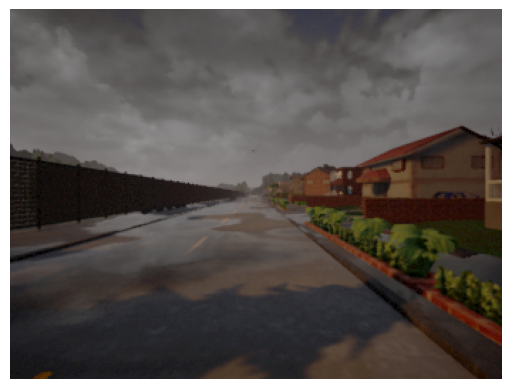

In [38]:
plt.imshow(img.to('cpu').permute(1, 2, 0))
plt.axis('off')
plt.show()

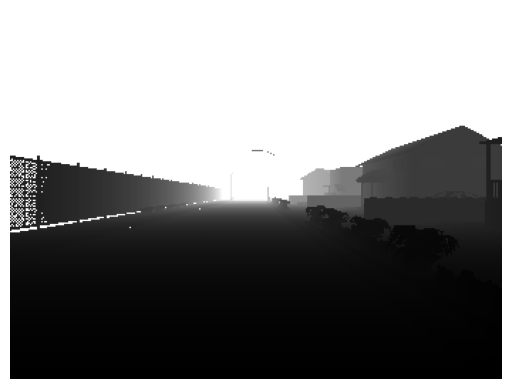

In [39]:
plt.imshow(depth.to('cpu'), cmap='gray')
plt.axis('off')
plt.show()

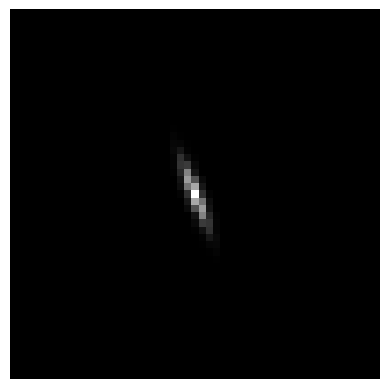

In [40]:
plt.imshow(get_psf(20), cmap='gray')
plt.axis('off')
plt.show()

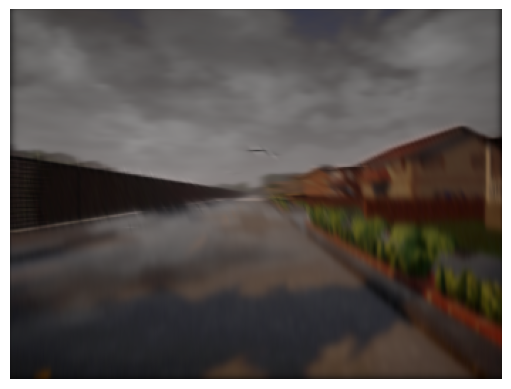

In [41]:
plt.imshow(final_image.to('cpu').permute(1, 2, 0))
plt.axis('off')
plt.show()

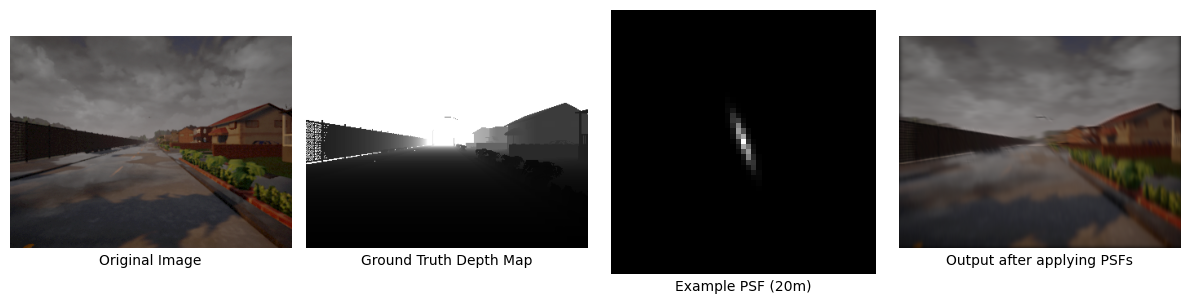

In [42]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))  # 1 row, 4 columns

axes[0].imshow(img.to('cpu').permute(1, 2, 0))
axes[0].set_xlabel("Original Image")

axes[1].imshow(depth.to('cpu'), cmap='gray')
axes[1].set_xlabel("Ground Truth Depth Map")

axes[2].imshow(get_psf(20), cmap='gray')
axes[2].set_xlabel("Example PSF (20m)")

axes[3].imshow(final_image.to('cpu').permute(1, 2, 0))
axes[3].set_xlabel("Output after applying PSFs")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig("experiment.png", dpi=300, bbox_inches='tight')
plt.show()